# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_airbnb_data_6.csv')

display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20251107023918,2025-11-07,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.22,4.56,3.22,3.67,f,1,1,0,0,0.07
1,3820211,https://www.airbnb.com/rooms/3820211,20251107023918,2025-11-07,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.85,4.81,4.82,4.78,f,5,5,0,0,2.30
2,5651579,https://www.airbnb.com/rooms/5651579,20251107023918,2025-11-07,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",The neighborhood is very eclectic. We have a v...,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.81,4.88,4.77,4.64,f,2,1,1,0,2.95
3,6623339,https://www.airbnb.com/rooms/6623339,20251107023918,2025-11-07,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,Overview<br /><br />The lovely apartment is lo...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.83,4.70,4.80,4.72,f,5,5,0,0,2.62
4,9005989,https://www.airbnb.com/rooms/9005989,20251107023918,2025-11-07,city scrape,"Studio in The heart of Center SQ, in Albany NY",(21 years of age or older ONLY) NON- SMOKING.....,"There are many shops, restaurants, bars, museu...",https://a0.muscache.com/pictures/d242a77e-437c...,17766924,...,4.95,4.93,4.87,4.77,f,1,1,0,0,5.53


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



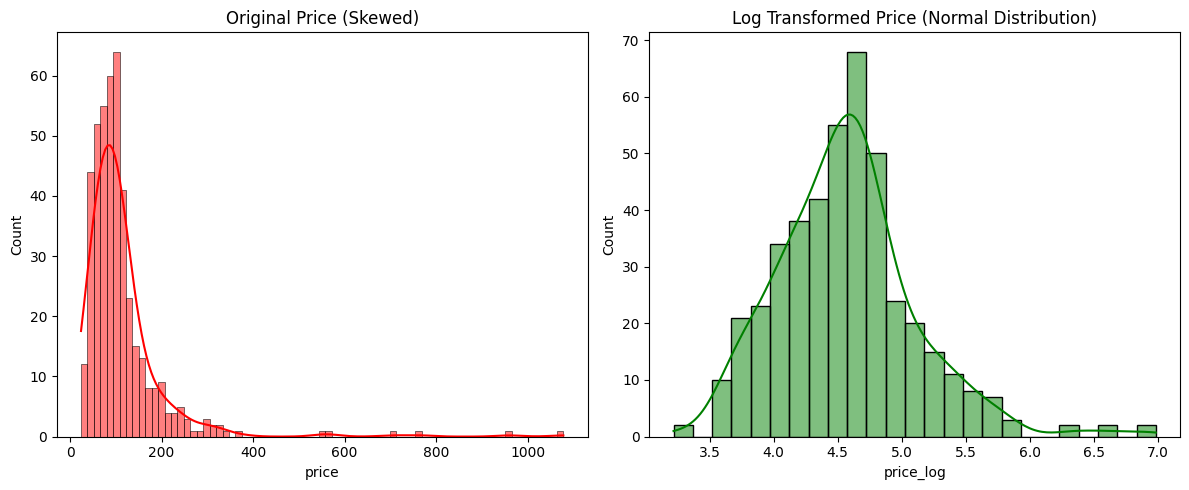

In [4]:
# Add code here 🔧
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, color='red')
plt.title('Original Price (Skewed)')

df['price_log'] = np.log1p(df['price'])

plt.subplot(1, 2, 2)
sns.histplot(df['price_log'], kde=True, color='green')
plt.title('Log Transformed Price (Normal Distribution)')

plt.tight_layout()
plt.show()

### ✍️ Your Response: 🔧
1. I checked out the price column

2. I used the log transformation because it takes the high end outliers towards the middle more.

3. This helps because there was just a huge spike on the left with nothing else. New chart looks like a bell curve making it easier to see pricing without luxury ruining the average.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [7]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

mm_scaler = MinMaxScaler()

# Min-Max scale
df['rating_minmax'] = mm_scaler.fit_transform(df[['review_scores_rating']])

# Z-score scale
z_scaler = StandardScaler()
df['price_zscore'] = z_scaler.fit_transform(df[['price']])

df[['review_scores_rating', 'rating_minmax', 'price', 'price_zscore']].head()

,review_scores_rating,rating_minmax,price,price_zscore
0,3.56,0.6400,70.0,-0.442657
1,4.75,0.9375,86.0,-0.280561
2,4.52,0.8800,64.0,-0.503443
3,4.73,0.9325,85.0,-0.290692
4,4.79,0.9475,85.0,-0.290692


### ✍️ Your Response: 🔧
1. I chose to do price with z score and review score rating with min max.

2. The z score would help price so the high prices don't drown out the rest.

3. A data scientist would benefit most as preprocessing to make their predictive algorithms work correctly.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [8]:
# Add code here
df['review_volume'] = pd.cut(df['number_of_reviews'], bins=3, labels=["Low", "Medium", "High"])

print(df['review_volume'].value_counts())

df[['number_of_reviews', 'review_volume']].head()

review_volume
Low       462
Medium     12
High        4
Name: count, dtype: int64


,number_of_reviews,review_volume
0,9,Low
1,314,Low
2,377,Medium
3,332,Medium
4,623,Medium


### ✍️ Your Response: 🔧
1. I grouped number of reviews into 3 categories.

2. Chose these because its easier to compare listing with over 100 reviews with similar ones to that number vs something really low.

3. The marketing team would like this and they could use it to label stays as a top performer or something like that.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [9]:
# Add code here
df['price_per_person'] = df['price'] / df['accommodates']

df['is_long_term'] = df['minimum_nights'] >= 30

df[['price', 'accommodates', 'price_per_person', 'minimum_nights', 'is_long_term']].head()

,price,accommodates,price_per_person,minimum_nights,is_long_term
0,70.0,4,17.500000,28,False
1,86.0,3,28.666667,2,False
2,64.0,2,32.000000,2,False
3,85.0,2,42.500000,2,False
4,85.0,4,21.250000,1,False


### ✍️ Your Response: 🔧 🔧
1. I created price per person ratio and is long term as true or false.

2. A host would use these to see if they are good for group booking. Maybe a city planner would use them do see how many listings are taking long term housing off the market.

3. It helps hosts decide if they should lower prices to attract more groups.



## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [10]:
# Add code here
df_final = pd.get_dummies(df, columns=['room_type'], prefix='type')

print(f"Original columns: {df.shape[1]}")
print(f"New columns: {df_final.shape[1]}")

df_final.filter(like='type_').head()

Original columns: 82
New columns: 84


,type_Entire home/apt,type_Hotel room,type_Private room
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


### ✍️ Your Response: 🔧
1. Encoded room type because the type of room is a big factor in price and since it is a text the model can't process it.

2. I used one hot encoding since there is no rank betwen shared room and private room so separating into binary coluns is best.

3. This is big for pricing model and allows algorithm to calcuate how extra value of an entire home vs private room so better price suggestion.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [11]:
# export csv here 🔧
df_final.to_csv('cleaned_airbnb_data_7.csv', index=False)

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. I think the one hot encoding was interesting to turn words into 1s and 0s so a computer can understand the data better. Without it the computer would be blind to the whole thing really.

2. The is long term flag is a big deal for a city planner. It would let them see what listing are actually long term rentals vs short vacation spots for policies and zoning.

3. I would build a value dashboard using price per person ration and it would help travelers find the cheapest stays for large groups where cost per person is the lowest.

4. This connects to my customized learning outcome by learning how to data prep and cleaning data is only half of the process, transformation is where big changes happen to make the computer understand data more.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [12]:
!jupyter nbconvert --to html "assignment_07_rosolowski_evan.ipynb"

[NbConvertApp] Converting notebook assignment_07_rosolowski_evan.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 399612 bytes to assignment_07_rosolowski_evan.html
